In [10]:
import pandas as pd
import numpy as np

dataset = pd.read_csv("ipl_final_dataset.csv")

print(dataset.head(5))

   match_id        date                                       venue  \
0    335982  2008-04-18                       M Chinnaswamy Stadium   
1    335983  2008-04-19  Punjab Cricket Association Stadium, Mohali   
2    335984  2008-04-19                            Feroz Shah Kotla   
3    335985  2008-04-20                            Wankhede Stadium   
4    335986  2008-04-20                                Eden Gardens   

                   team1                        team2  \
0  Kolkata Knight Riders  Royal Challengers Bangalore   
1    Chennai Super Kings              Kings XI Punjab   
2       Rajasthan Royals             Delhi Daredevils   
3         Mumbai Indians  Royal Challengers Bangalore   
4        Deccan Chargers        Kolkata Knight Riders   

                   toss_winner toss_decision                       winner  \
0  Royal Challengers Bangalore         field        Kolkata Knight Riders   
1          Chennai Super Kings           bat          Chennai Super Kings   

In [11]:
print(dataset.tail(5))

      match_id        date                                              venue  \
1106   1473449  2025-03-31                           Wankhede Stadium, Mumbai   
1107   1473450  2025-04-01  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...   
1108   1473451  2025-04-02                   M Chinnaswamy Stadium, Bengaluru   
1109   1473452  2025-04-03                              Eden Gardens, Kolkata   
1110   1473453  2025-04-04  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...   

                            team1                team2          toss_winner  \
1106        Kolkata Knight Riders       Mumbai Indians       Mumbai Indians   
1107         Lucknow Super Giants         Punjab Kings         Punjab Kings   
1108  Royal Challengers Bengaluru       Gujarat Titans       Gujarat Titans   
1109        Kolkata Knight Riders  Sunrisers Hyderabad  Sunrisers Hyderabad   
1110         Lucknow Super Giants       Mumbai Indians       Mumbai Indians   

     toss_decision                 win

In [12]:
dataset = dataset.dropna(subset=['winner'])

print(dataset.head())

   match_id        date                                       venue  \
0    335982  2008-04-18                       M Chinnaswamy Stadium   
1    335983  2008-04-19  Punjab Cricket Association Stadium, Mohali   
2    335984  2008-04-19                            Feroz Shah Kotla   
3    335985  2008-04-20                            Wankhede Stadium   
4    335986  2008-04-20                                Eden Gardens   

                   team1                        team2  \
0  Kolkata Knight Riders  Royal Challengers Bangalore   
1    Chennai Super Kings              Kings XI Punjab   
2       Rajasthan Royals             Delhi Daredevils   
3         Mumbai Indians  Royal Challengers Bangalore   
4        Deccan Chargers        Kolkata Knight Riders   

                   toss_winner toss_decision                       winner  \
0  Royal Challengers Bangalore         field        Kolkata Knight Riders   
1          Chennai Super Kings           bat          Chennai Super Kings   

In [13]:
def get_winner_slot(row):
    if row['winner'] == row['team1']:
        return 1
    else:
        return 0

In [14]:
def get_toss_winner_slot(row):
    if row['toss_winner'] == row['team1']:
        return 1
    else:
        return 0

In [15]:
dataset['winner_slot'] = dataset.apply(get_winner_slot, axis=1)
dataset['toss_winner_slot'] = dataset.apply(get_toss_winner_slot, axis=1)

print(dataset.head(5))

   match_id        date                                       venue  \
0    335982  2008-04-18                       M Chinnaswamy Stadium   
1    335983  2008-04-19  Punjab Cricket Association Stadium, Mohali   
2    335984  2008-04-19                            Feroz Shah Kotla   
3    335985  2008-04-20                            Wankhede Stadium   
4    335986  2008-04-20                                Eden Gardens   

                   team1                        team2  \
0  Kolkata Knight Riders  Royal Challengers Bangalore   
1    Chennai Super Kings              Kings XI Punjab   
2       Rajasthan Royals             Delhi Daredevils   
3         Mumbai Indians  Royal Challengers Bangalore   
4        Deccan Chargers        Kolkata Knight Riders   

                   toss_winner toss_decision                       winner  \
0  Royal Challengers Bangalore         field        Kolkata Knight Riders   
1          Chennai Super Kings           bat          Chennai Super Kings   

In [16]:
# I have removed the non-numerical data and toss-winner and winner 
# because i already have winner and toss-winner in winner_slot and toss_slot which are in 0 or 1 unlike RCB, CSK, SRH, 
# also team1 score and team2 score because if i have them, then there is not point in using machine learning to predict result

dataset = dataset.drop(["date", "venue", "result", "toss_winner",
                        "toss_decision", "team1", "team2",
                        "team1_score", 
                        "team2_score", 
                        "team1_players", 
                        "team2_players", "winner"], axis=1)

dataset = dataset.set_index("match_id")

print(dataset.head(5))

          venue_avg_score  chasing_win_rate_venue  team1_win_rate_at_venue  \
match_id                                                                     
335982                0.0                     0.0                      0.0   
335983                0.0                     0.0                      0.0   
335984                0.0                     0.0                      0.0   
335985                0.0                     0.0                      0.0   
335986                0.0                     0.0                      0.0   

          team2_win_rate_at_venue  team1_total_wins_against_team2  \
match_id                                                            
335982                        0.0                             0.0   
335983                        0.0                             0.0   
335984                        0.0                             0.0   
335985                        0.0                             0.0   
335986                        0.0      

In [17]:
dataset.to_csv("ipl_final_training_with_team1_score.csv")

In [18]:
# from sklearn.preprocessing import StandardScaler

# standard_dataset_array = StandardScaler().fit_transform(dataset.iloc[:, 1:])
# standard_dataset = pd.DataFrame(standard_dataset_array, columns = dataset.columns[1:])
# print(standard_dataset)

# # I have removed the non-numerical data and toss-winner and winner 
# # because i already have winner and toss-winner in winner_slot and toss_slot which are in 0 or 1 unlike RCB, CSK, SRH, 
# # also team1 score and team2 score because if i have them, then there is not point in using machine learning to predict result

# standard_dataset = standard_dataset.drop(["date", "venue", "result", "toss_winner",
#                         "toss_decision", "team1", "team2",
#                         "team1_score", 
#                         "team2_score", 
#                         "team1_players", 
#                         "team2_players", "winner"], axis=1)

# standard_dataset = standard_dataset.set_index("match_id")

# print(dataset.head(5))

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [20]:
cols = list(dataset.columns)
cols.remove("winner_slot")
cols = ["winner_slot"] + cols
dataset = dataset[cols]

In [21]:
print(dataset.head(5))

          winner_slot  venue_avg_score  chasing_win_rate_venue  \
match_id                                                         
335982              1              0.0                     0.0   
335983              1              0.0                     0.0   
335984              0              0.0                     0.0   
335985              0              0.0                     0.0   
335986              0              0.0                     0.0   

          team1_win_rate_at_venue  team2_win_rate_at_venue  \
match_id                                                     
335982                        0.0                      0.0   
335983                        0.0                      0.0   
335984                        0.0                      0.0   
335985                        0.0                      0.0   
335986                        0.0                      0.0   

          team1_total_wins_against_team2  team2_total_wins_against_team1  \
match_id                  

In [22]:
target_value = [0]
print(dataset.columns[target_value])

Index(['winner_slot'], dtype='object')


In [23]:
input_values = range(1, dataset.columns.shape[0])

print(dataset.columns[input_values])

Index(['venue_avg_score', 'chasing_win_rate_venue', 'team1_win_rate_at_venue',
       'team2_win_rate_at_venue', 'team1_total_wins_against_team2',
       'team2_total_wins_against_team1', 'team1_wins_against_team2_last_three',
       'team2_wins_against_team1_last_three', 'team1_form_last_5',
       'team2_form_last_5', 'team1_last_5_avg_score',
       'team1_last_5_runs_conceded', 'team2_last_5_avg_score',
       'team2_last_5_runs_conceded', 'team1_chasing_win_rate',
       'team1_defending_win_rate', 'team2_chasing_win_rate',
       'team2_defending_win_rate', 'toss_winner_slot'],
      dtype='object')


In [24]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

x = dataset.iloc[:, input_values]
y = dataset.iloc[:, target_value]

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.3, random_state=50)

model.fit(X_train, Y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(Y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))


Accuracy: 0.5030
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.55      0.54       174
           1       0.47      0.45      0.46       154

    accuracy                           0.50       328
   macro avg       0.50      0.50      0.50       328
weighted avg       0.50      0.50      0.50       328

Confusion Matrix:
 [[95 79]
 [84 70]]


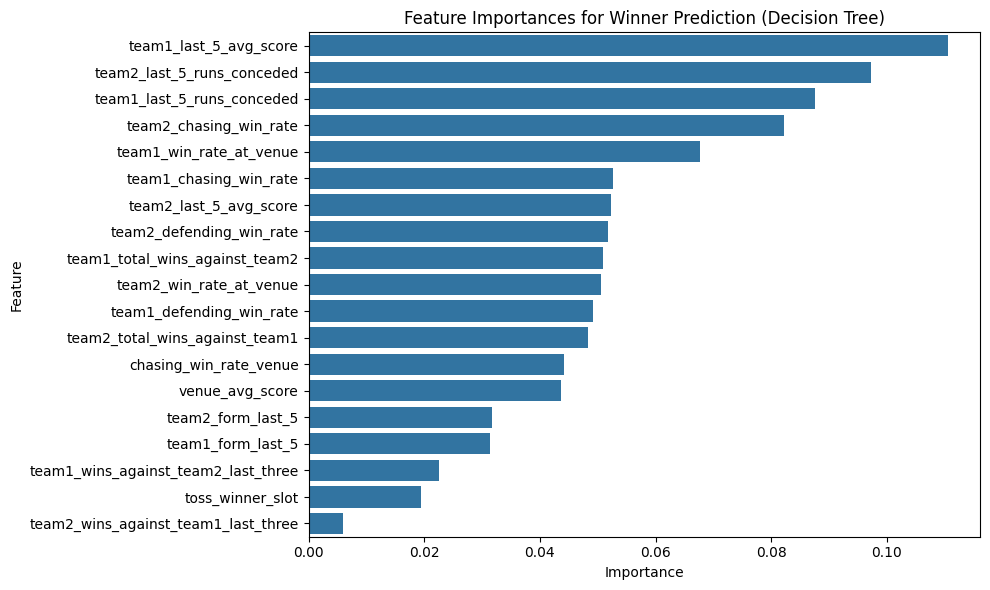

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
features = x.columns

# Sort by importance
sorted_indices = importances.argsort()[::-1]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_indices], y=features[sorted_indices])
plt.title("Feature Importances for Winner Prediction (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [26]:
model = RandomForestClassifier()

x = dataset.iloc[:, input_values]
y = dataset.iloc[:, target_value]

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.3 , random_state = 50)

model.fit(X_train, Y_train)
predictions = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(Y_test, predictions)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))

c:\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 0.5030
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.64      0.58       174
           1       0.46      0.34      0.39       154

    accuracy                           0.50       328
   macro avg       0.49      0.49      0.49       328
weighted avg       0.50      0.50      0.49       328

Confusion Matrix:
 [[112  62]
 [101  53]]


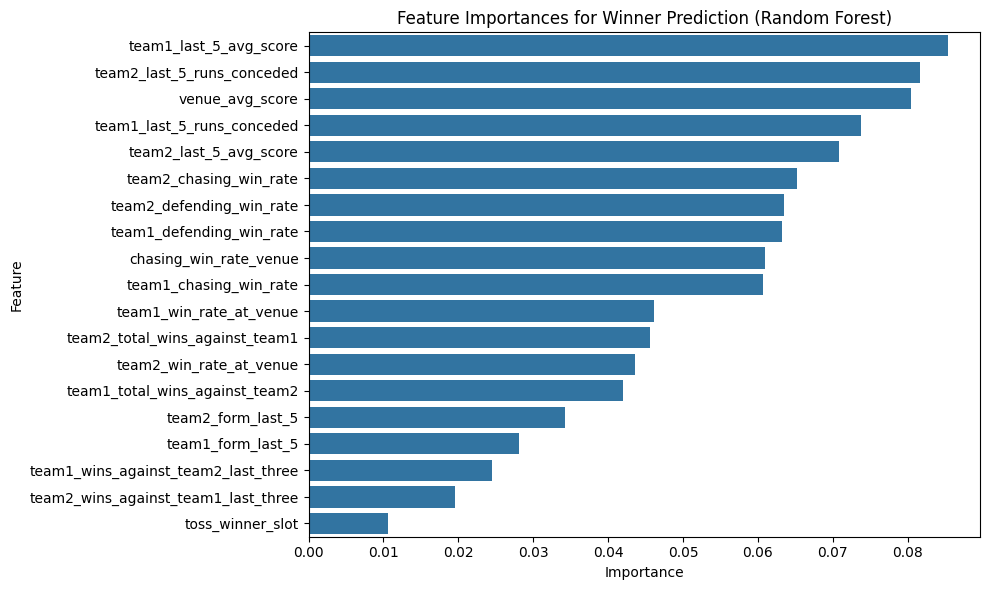

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
features = x.columns

# Sort by importance
sorted_indices = importances.argsort()[::-1]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_indices], y=features[sorted_indices])
plt.title("Feature Importances for Winner Prediction (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [28]:
print(standard_dataset.columns)

Index(['chasing_win_rate_venue', 'team1_win_rate_at_venue',
       'team2_win_rate_at_venue', 'team1_total_wins_against_team2',
       'team2_total_wins_against_team1', 'team1_wins_against_team2_last_three',
       'team2_wins_against_team1_last_three', 'team1_form_last_5',
       'team2_form_last_5', 'team1_last_5_avg_score',
       'team1_last_5_runs_conceded', 'team2_last_5_avg_score',
       'team2_last_5_runs_conceded', 'team1_chasing_win_rate',
       'team1_defending_win_rate', 'team2_chasing_win_rate',
       'team2_defending_win_rate', 'winner_slot', 'toss_winner_slot'],
      dtype='object')


In [29]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

model = SVC(kernel='rbf')

x = dataset.iloc[:, input_values]
y = dataset.iloc[:, target_value]

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.3, random_state=50)

model.fit(X_train, Y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(Y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))


Accuracy: 0.5305
Classification Report:
               precision    recall  f1-score   support

           0       0.53      1.00      0.69       174
           1       0.00      0.00      0.00       154

    accuracy                           0.53       328
   macro avg       0.27      0.50      0.35       328
weighted avg       0.28      0.53      0.37       328

Confusion Matrix:
 [[174   0]
 [154   0]]


c:\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being

In [30]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# importance = model.coef_[0]  # For binary classification
# features = x.columns

# # Sort by absolute importance
# sorted_indices = np.argsort(np.abs(importance))[::-1]
# sorted_importance = np.abs(importance)[sorted_indices]
# sorted_features = features[sorted_indices]

# plt.figure(figsize=(10, 6))
# sns.barplot(x=sorted_importance, y=sorted_features)
# plt.title("Feature Importance (Coefficient Magnitude)")
# plt.xlabel("Importance")
# plt.ylabel("Feature")
# plt.tight_layout()
# plt.show()


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

x = dataset.iloc[:,input_values]
y = dataset.iloc[:, target_value]

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.3, random_state=50)

model.fit(X_train, Y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(Y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))


c:\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.5030
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.69      0.60       174
           1       0.45      0.29      0.36       154

    accuracy                           0.50       328
   macro avg       0.49      0.49      0.48       328
weighted avg       0.49      0.50      0.48       328

Confusion Matrix:
 [[120  54]
 [109  45]]


c:\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


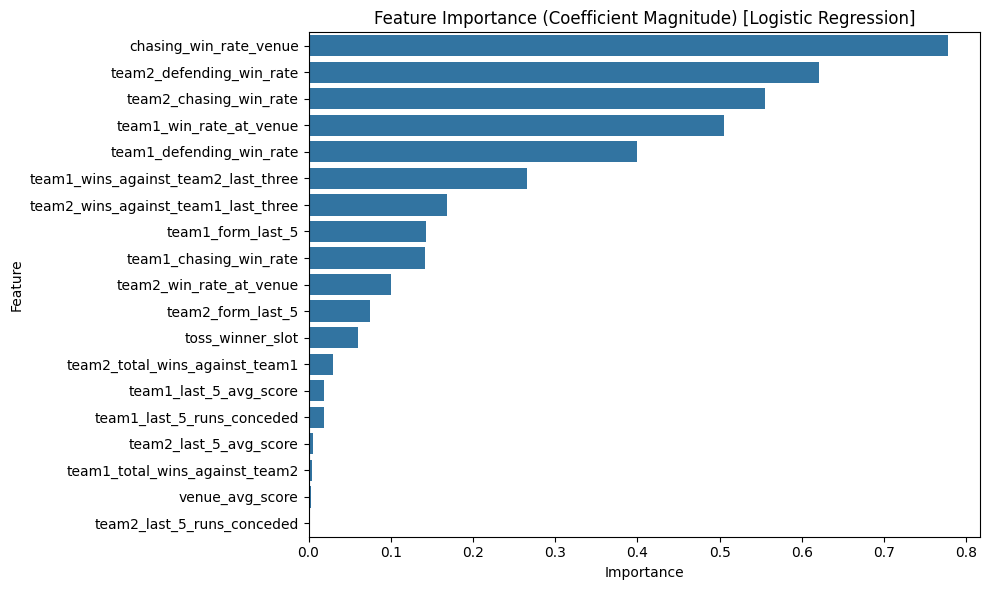

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

importance = model.coef_[0]  # For binary classification
features = x.columns

# Sort by absolute importance
sorted_indices = np.argsort(np.abs(importance))[::-1]
sorted_importance = np.abs(importance)[sorted_indices]
sorted_features = features[sorted_indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importance, y=sorted_features)
plt.title("Feature Importance (Coefficient Magnitude) [Logistic Regression]")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [33]:
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()

x = dataset.iloc[:, input_values]
y = dataset.iloc[:, target_value]

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.3, random_state=50)

model.fit(X_train, Y_train)
preds_continuous = model.predict(X_test)

# Convert continuous output to class labels (binary classification assumed)
predictions = np.round(preds_continuous).astype(int)

accuracy = accuracy_score(Y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))


Accuracy: 0.5122
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.70      0.60       174
           1       0.47      0.31      0.37       154

    accuracy                           0.51       328
   macro avg       0.50      0.50      0.49       328
weighted avg       0.50      0.51      0.49       328

Confusion Matrix:
 [[121  53]
 [107  47]]


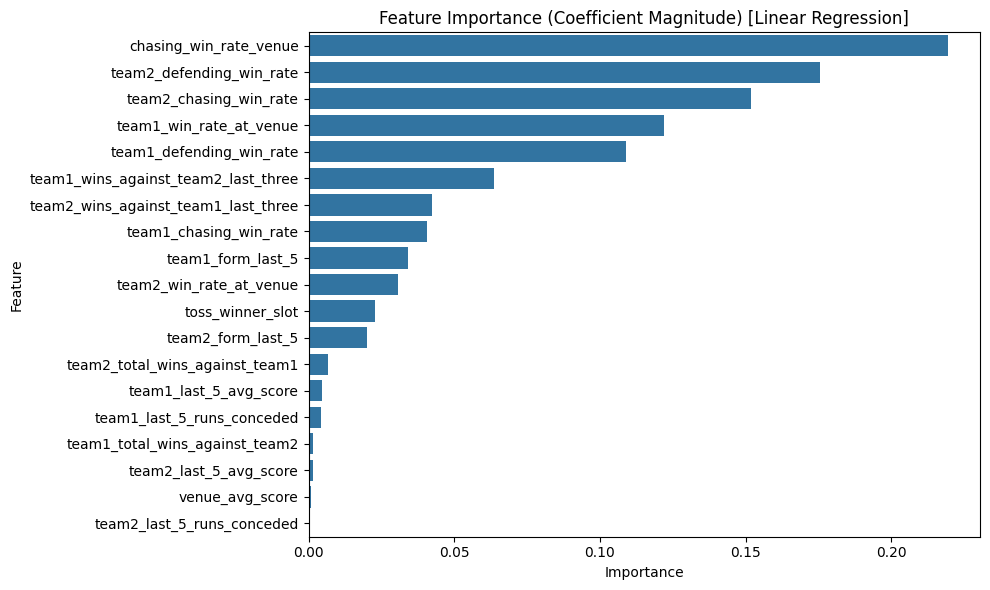

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

importance = model.coef_[0]  # For binary classification
features = x.columns

# Sort by absolute importance
sorted_indices = np.argsort(np.abs(importance))[::-1]
sorted_importance = np.abs(importance)[sorted_indices]
sorted_features = features[sorted_indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importance, y=sorted_features)
plt.title("Feature Importance (Coefficient Magnitude) [Linear Regression]")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [35]:
print(dataset.columns[input_values])

# Confirm class balance
print(y.value_counts(normalize=True))
print(y.shape)

Index(['venue_avg_score', 'chasing_win_rate_venue', 'team1_win_rate_at_venue',
       'team2_win_rate_at_venue', 'team1_total_wins_against_team2',
       'team2_total_wins_against_team1', 'team1_wins_against_team2_last_three',
       'team2_wins_against_team1_last_three', 'team1_form_last_5',
       'team2_form_last_5', 'team1_last_5_avg_score',
       'team1_last_5_runs_conceded', 'team2_last_5_avg_score',
       'team2_last_5_runs_conceded', 'team1_chasing_win_rate',
       'team1_defending_win_rate', 'team2_chasing_win_rate',
       'team2_defending_win_rate', 'toss_winner_slot'],
      dtype='object')
winner_slot
0              0.54304
1              0.45696
Name: proportion, dtype: float64
(1092, 1)


In [36]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Use your existing dataset and input/target values
x = dataset.iloc[:, input_values]
y = dataset.iloc[:, target_value]

# Flatten y if it's a DataFrame
y = y.values.ravel()

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=70)

# Create and train the model
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, Y_train)

# Predict and evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(Y_test, predictions)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))


c:\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [04:48:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.4612
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.54      0.52       116
           1       0.42      0.37      0.39       103

    accuracy                           0.46       219
   macro avg       0.45      0.46      0.45       219
weighted avg       0.46      0.46      0.46       219

Confusion Matrix:
 [[63 53]
 [65 38]]


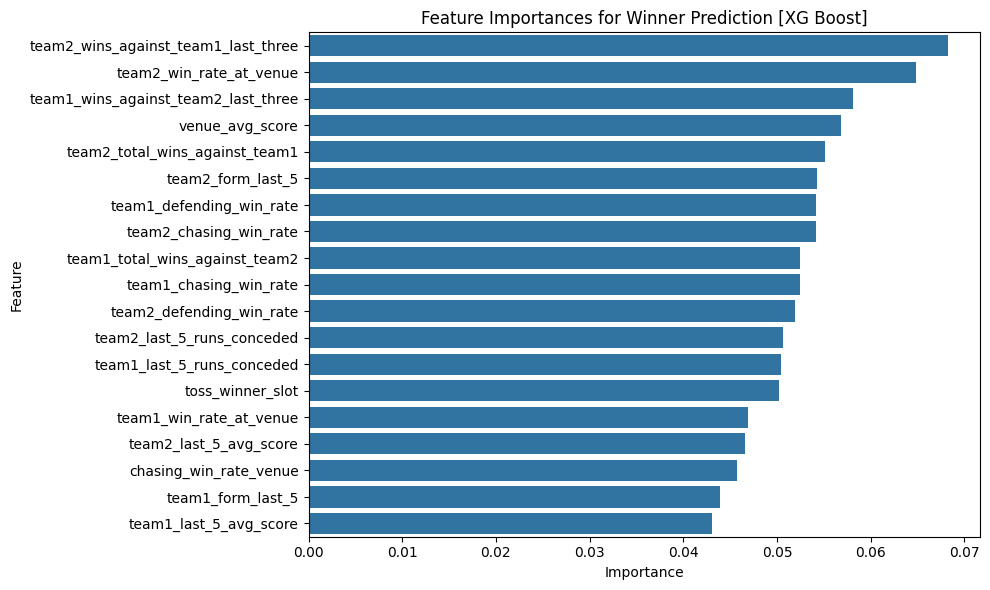

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
features = x.columns

# Sort by importance
sorted_indices = importances.argsort()[::-1]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_indices], y=features[sorted_indices])
plt.title("Feature Importances for Winner Prediction [XG Boost]")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()